Introduction

This notebook presents an exploratory analysis of a synthetically generated marketing campaign dataset comprising 200,000 campaign records across multiple companies, campaign types, channels, customer segments, and durations. The dataset was sourced from Kaggle and is intended to simulate real-world marketing campaign performance data.

The analysis is structured around the four questions:
1. Which campaign type drives the highest average ROI?
2. Which channel yields the highest average conversion rate?
3. Which customer segment can be acquired most cost-efficiently?
4. Does campaign duration have a meaningful relationship with ROI?

These questions aim to identify where budget generates the greatest return, which channels drive behavioural change most effectively, which audiences are most capital efficient to target, and whether campaign parameters such as duration represent actionable inputs for performance optimisation.
All analysis was conducted in Python using pandas and matplotlib. Charts are saved to the outputs directory for reference.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
campaign_data = pd.read_csv('data/marketing_campaign_dataset.csv')

# Inspect data
print(campaign_data.shape)
print(campaign_data.head())
print(campaign_data.columns.tolist())
print(campaign_data.isnull().sum())

(200000, 16)
   Campaign_ID              Company Campaign_Type Target_Audience Duration  \
0            1  Innovate Industries         Email       Men 18-24  30 days   
1            2       NexGen Systems         Email     Women 35-44  60 days   
2            3    Alpha Innovations    Influencer       Men 25-34  30 days   
3            4   DataTech Solutions       Display        All Ages  60 days   
4            5       NexGen Systems         Email       Men 25-34  15 days   

  Channel_Used  Conversion_Rate Acquisition_Cost   ROI     Location  Language  \
0   Google Ads             0.04       $16,174.00  6.29      Chicago   Spanish   
1   Google Ads             0.12       $11,566.00  5.61     New York    German   
2      YouTube             0.07       $10,200.00  7.18  Los Angeles    French   
3      YouTube             0.11       $12,724.00  5.55        Miami  Mandarin   
4      YouTube             0.05       $16,452.00  6.50  Los Angeles  Mandarin   

   Clicks  Impressions  Engagem

In [35]:
# Clean the required data, ready for analysis.
# Clean Acquisition_Cost by removing $ and commas, convert to float.
campaign_data['Acquisition_Cost'] = campaign_data['Acquisition_Cost'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

# Clean Duration by removing ' days', convert to integer.
campaign_data['Duration'] = campaign_data['Duration'].str.replace(' days', '', regex=False).astype(int)


# Check to see if the data is formatted correctly and ready for analysis.
print(campaign_data[['Acquisition_Cost', 'Duration']].head())
print(campaign_data[['Acquisition_Cost', 'Duration']].dtypes)

   Acquisition_Cost  Duration
0           16174.0        30
1           11566.0        60
2           10200.0        30
3           12724.0        60
4           16452.0        15
Acquisition_Cost    float64
Duration              int64
dtype: object


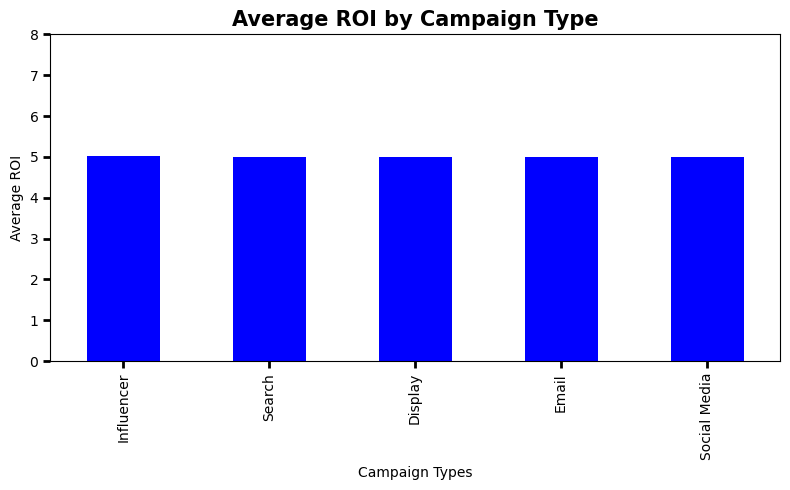

Campaign_Type
Influencer      5.011068
Search          5.008357
Display         5.006551
Email           4.994295
Social Media    4.991784
Name: ROI, dtype: float64


In [ ]:
# First we find which campaign type drives the highest ROI.
roi_by_campaign = campaign_data.groupby('Campaign_Type')['ROI'].mean().sort_values(ascending=False)

# Plotting the data.
fig, ax = plt.subplots(figsize=(8,5))
roi_by_campaign.plot(kind='bar', ax=ax, color='blue', width=0.5)
ax.set_title('Average ROI by Campaign Type', fontsize=15, fontweight='bold')
ax.set_xlabel('Campaign Types',fontsize=10)
ax.set_ylabel('Average ROI', fontsize=10)
ax.tick_params(axis = 'both',length=5, width=2)
ax.set_ylim(bottom=0, top=8)
plt.tight_layout()
plt.savefig('outputs/roi_by_campaign_type.png')
plt.show()
print(roi_by_campaign)

Campaign type alone appears to be a weak predictor of ROI. Influencer campaigns yield the highest average return at 5.01, yet the variance across all five campaign types spans less than 0.02 - a difference that is unlikely to be statistically or commercially significant at scale. This convergence suggests that the dataset's ROI distribution is driven by factors other than campaign type, and that allocating budget on this basis alone would be a poor strategic decision. A more rigorous approach would involve controlling for confounding variables - such as target audience, channel, and campaign duration - before drawing conclusions about which campaign type genuinely outperforms. The following analyses begin to unpick these relationships.

Conversion rate measures the proportion of audience members who take a desired action following campaign exposure. Unlike ROI, which captures overall return, conversion rate isolates the effectiveness of a channel at driving behavioural change - making it a more granular indicator of channel efficiency. The analysis below examines average conversion rate across each channel to identify where audience engagement translates most reliably into action.

Channel_Used
Email         0.080282
Google Ads    0.080183
Website       0.080183
Facebook      0.079992
YouTube       0.079889
Instagram     0.079886
Name: Conversion_Rate, dtype: float64


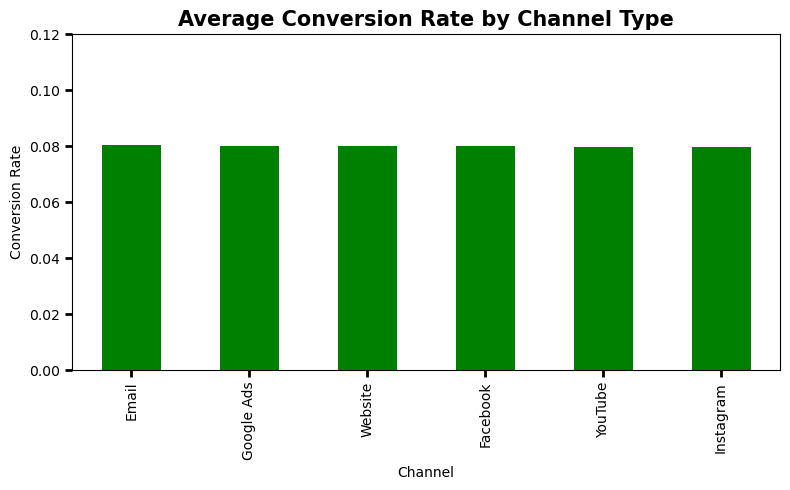

In [ ]:
# Now to compare the conversion rate of each channel type.
conversion_by_channel = campaign_data.groupby('Channel_Used')['Conversion_Rate'].mean().sort_values(ascending=False)

# Plotting the data.
fig, ax = plt.subplots(figsize = (8,5))
conversion_by_channel.plot(kind='bar', color='green', width=0.5)
ax.set_title('Average Conversion Rate by Channel Type',fontsize=15, fontweight='bold')
ax.set_xlabel('Channel', fontsize=10)
ax.set_ylabel('Conversion Rate',fontsize=10)
ax.tick_params(axis='both', length=5, width=2)
ax.set_ylim(bottom=0, top=0.12)
plt.tight_layout()
plt.savefig('outputs/conversion_rate_by_channel')
print(conversion_by_channel)

As shown by the data Email delivers the highest average conversion rate at 8.03%, followed closely by Google Ads and Website at 8.02%. However, as with the previous ROI analysis, the variance across all six channels is negligible, spanning just 0.04 percentage points from the highest to the lowest performing channel. This consistency suggests that channel selection alone is an insufficient basis for campaign optimisation, and that performance differentiation is likely driven by upstream decisions around audience segmentation, messaging relevance, and creative quality rather than channel mechanics. For a marketer, this would point towards an audience-first planning approach where the target segment determines the channel mix, rather than the channel being selected independently of audience behaviour. The next analysis will examine acquisition cost by customer segment to explore whether more actionable differentiation exists at the audience level.

Acquisition cost is the investment required to convert a new customer within a given segment. Identifying which segments can be acquired most efficiently is a critical input for budget allocation decisions, especially in organisations where capital efficiency is a priority. Combining a low acquisition cost with a comparable or superior lifetime value will identify a high priority segment for investment.

Customer_Segment
Foodies                12524.558148
Outdoor Adventurers    12509.128540
Health & Wellness      12504.418346
Fashionistas           12503.445574
Tech Enthusiasts       12480.392991
Name: Acquisition_Cost, dtype: float64


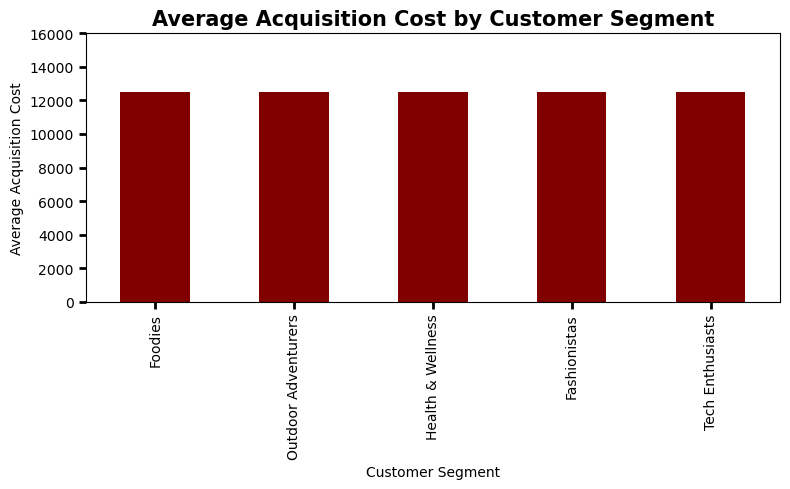

In [ ]:
# Average acquisition cost by customer segment.
acquisition_by_segment = campaign_data.groupby('Customer_Segment')['Acquisition_Cost'].mean().sort_values(ascending=False)

# Plotting the data.
fig, ax = plt.subplots(figsize=(8,5))
acquisition_by_segment.plot(kind='bar', color='maroon', width=0.5)
ax.set_title('Average Acquisition Cost by Customer Segment', fontsize=15, fontweight='bold')
ax.set_xlabel('Customer Segment', fontsize=10)
ax.set_ylabel('Average Acquisition Cost', fontsize=10)
ax.tick_params(axis='both', length=5, width=2)
ax.set_ylim(top=16000)
plt.tight_layout()
plt.savefig('outputs/acquisition_by_segment.png')
print(acquisition_by_segment)

The Tech Enthusiasts represent the most capital efficent segment to acquire at a cost of $12480, meanwhile the most expensive segment, Foodie, demands the average cost of $12,524. The spread across segments is $44, which similar to analyses of ROI and Conversion Rate, the variance can be deemed negligible. This reinforces a pattern that has emerged throughout this notebook: standard campaign performance metrics - ROI, conversion rate, and acquisition cost - show remarkably little differentiation across campaign types, channels, and customer segments in this dataset. This convergence is itself significant as rather than indicating that these variables lack impact, it suggests that aggregating performance metrics across multiple companies may be obscuring meaningful firm-level variance, a statistical limitation known as the ecological fallacy, whereby aggregate-level patterns cannot be reliably attributed to the behaviour of individual firms within the dataset. This is an important limitation of cross-company aggregate analysis, and one that would need to be expanded on in a real world environment by conducting firm-level analysis before drawing strategic conclusions. It should also be noted that this dataset is synthetically generated, which likely accounts for the absence of meaningful variance across segments.

Having established that campaign type, channel, and customer segment yield negligible performance differentiation at the aggregate level, the following analysis will examine whether campaign duration has a more meaningful relationship with ROI. Duration is a controllable variable, unlike audience demographics or channel availability, it is a variable that marketing teams can adjust. If a statistically meaningful relationship exists between duration and ROI, it would represent one of the few actionable optimisation insights this dataset can yield.

Pearson Correlation Coefficient: 0.0012
[30 60 15 45]


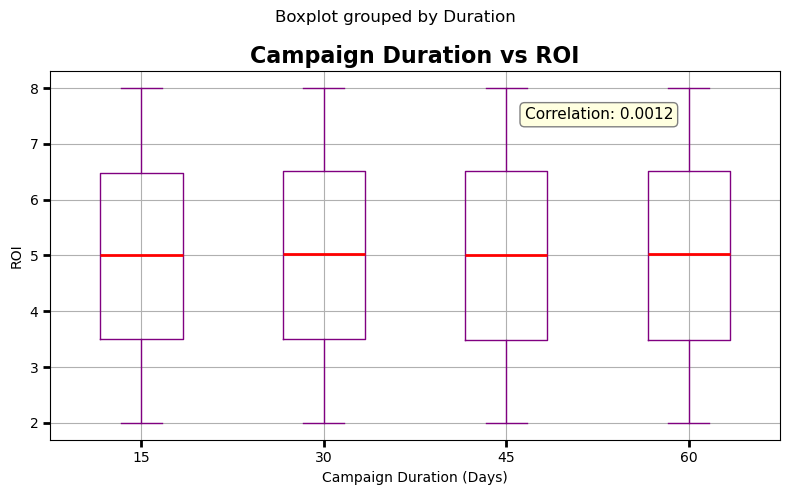

In [56]:
# Campaign duration against ROI.
correlation_duration_roi = campaign_data['Duration'].corr(campaign_data['ROI'])

# Plotting the data.
fig, ax = plt.subplots(figsize = (8,5))
campaign_data.boxplot(column='ROI', by='Duration', ax=ax, 
                      boxprops=dict(color='purple'),
                      medianprops=dict(color='red', linewidth=2),
                      whiskerprops=dict(color='purple'),
                      capprops=dict(color='purple'))

ax.set_title('Campaign Duration vs ROI', fontsize=16, fontweight='bold')
ax.set_xlabel('Campaign Duration (Days)', fontsize=10)
ax.set_ylabel('ROI', fontsize=10)
ax.tick_params(axis='both', length=5, width=2)

# Add correlation annotation to chart.
ax.annotate(f'Correlation: {correlation_duration_roi:.4f}', 
            xy=(0.65, 0.87),
            xycoords='axes fraction', 
            fontsize=11,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray'))

plt.tight_layout()
plt.savefig('outputs/duration_vs_roi', dpi=150)

print(f'Pearson Correlation Coefficient: {correlation_duration_roi:.4f}')
print(campaign_data['Duration'].unique())

The box plot reveals that ROI distribution is virtually identical across all four campaign durations: 15, 30, 45, and 60 days, with each duration yielding an interquartile range of 3.5 to 6.5 and whiskers extending from 2 to 8. The Pearson correlation coefficient of 0.0012 confirms what the visualisation already makes apparent, that there is no meaningful linear relationship between campaign duration and ROI. This finding is consistent with the pattern established across the earlier analyses. Taken together, the four analyses converge on a single overarching conclusion: in this dataset, none of the standard campaign variables examined: campaign type, channel, customer segment, or duration, demonstrate meaningful differentiation in ROI performance at the aggregate level. As previously discussed, this is most likely attributed to the ecological fallacy that arises inevitably in cross-company aggregate analysis, combined with the synthetically generated nature of the dataset. In a real-world context, these findings would prompt a shift in methodology, moving from aggregate-level analysis towards firm-level segmentation, logitudinal analysis, and multivariate modelling to isolate the true drivers of campaign performance.

Conclusion

This analysis set out to identify meaningful performance differentials across four key campaign variables: campaign type, channel, customer segment, and duration. Taken together, the findings converge on a single overarching conclusion: none of the variables demonstrate commercially meaningful differentiation in ROI, conversion rate, or acquisition cost at the aggregate level.
Three recommendations can be derived from this:
1. Avoid aggregate-level budget allocation decisions. The negligible variance observed across campaign types, channels, and segments is most attributable to the ecological fallacy arising from cross-company aggregate analysis, a methodological limitation whereby firm-level variance is obscured when data is collected across organisations. Therefore, strategic budget allocation decisions should be made at the firm level, not the aggregate level.
2. The focus should be shifted towards interaction effects. Univariate analysis (examining one variable at a time) has yielded limited actionable insight in this dataset. A multivariate modelling approach, incorporating regression analysis or decision tree methods, would better capture the interaction effects between campaign type, channel, audience, and duration that are likely driving performance differentials at the firm level.
3. Incorporate longitudinal analysis. The dataset spans two years and includes a date column that has not been utilised in this analysis. A longitudinal trend analysis looking at how campaign performance evolves over time would likely yield more actionable insights than the cross-sectional approach taken here. It would also enable the identification of seasonal patterns, campaign fatigue effects, and long-term ROI trends.

These recommendations reflect a broader analytical principle: the value of exploratory analysis lies not only in what the data reveals, but in what it signifies about the limitations of the current methodology and the direction for more rigorous investigation.